In [1]:
from readable_af.evaluation.evaluate import evaluate, load_summary_comparison
from pathlib import Path
import numpy as np
import pandas as pd

In [4]:
PROVIDER_MODELS = (
    ("anthropic", "claude-sonnet-5"),
    ("openai", "gpt-5.6-luna"),
    ("gemini", "gemini-3.7-flash")
)

In [5]:
df_rows=[]
for path in Path('../outputs').glob('*.json'):
    print(path)
    comparison=load_summary_comparison(path)
    for provider, model in PROVIDER_MODELS:
        for i in range(1): #range(6) -- number of times i want to run each to capture variability
            df_row={
                'file': path.with_suffix("").name,
            }
            this_eval = evaluate(comparison, provider, model_name=model)
            df_row["iteration"] = i
            df_row["provider"] = provider
            for field_name, value in this_eval:
                df_row[field_name] = value
            df_rows.append(df_row)
            
df = pd.DataFrame(df_rows)

../outputs/NoL6_Cond1.json
../outputs/JSLHR4_Cond1.json
../outputs/JSLHR1_Cond1.json
../outputs/NoL3_Cond1.json
../outputs/NoL4_Cond1.json
../outputs/JSLHR6_Cond1.json
../outputs/JSLHR3_Cond1.json
../outputs/NoL1_Cond1.json
../outputs/NoL2_Cond1.json
../outputs/NoL7_Cond1.json
../outputs/JSLHR5_Cond1.json
../outputs/JSLHR2_Cond1.json
Model invocation failed. Performing attempt number 2
../outputs/NoL5_Cond1.json
Model invocation failed. Performing attempt number 2
../outputs/JSLHR7_Cond1.json


In [6]:
df

,file,iteration,provider,accuracy,coverage,simplicity,clarity,naturalness,appropriateness_of_icons
0,NoL6_Cond1,0,anthropic,7,6,6,6,6,4
1,NoL6_Cond1,0,openai,7,6,7,7,8,4
2,NoL6_Cond1,0,gemini,8,8,4,5,7,8
3,JSLHR4_Cond1,0,anthropic,6,5,8,6,6,4
4,JSLHR4_Cond1,0,openai,6,5,6,6,7,5
5,JSLHR4_Cond1,0,gemini,7,7,5,6,6,6
6,JSLHR1_Cond1,0,anthropic,6,6,7,6,6,4
7,JSLHR1_Cond1,0,openai,7,7,7,7,5,6
8,JSLHR1_Cond1,0,gemini,8,9,6,7,6,4
9,NoL3_Cond1,0,anthropic,7,6,7,6,6,3


<Axes: xlabel='variable', ylabel='value'>

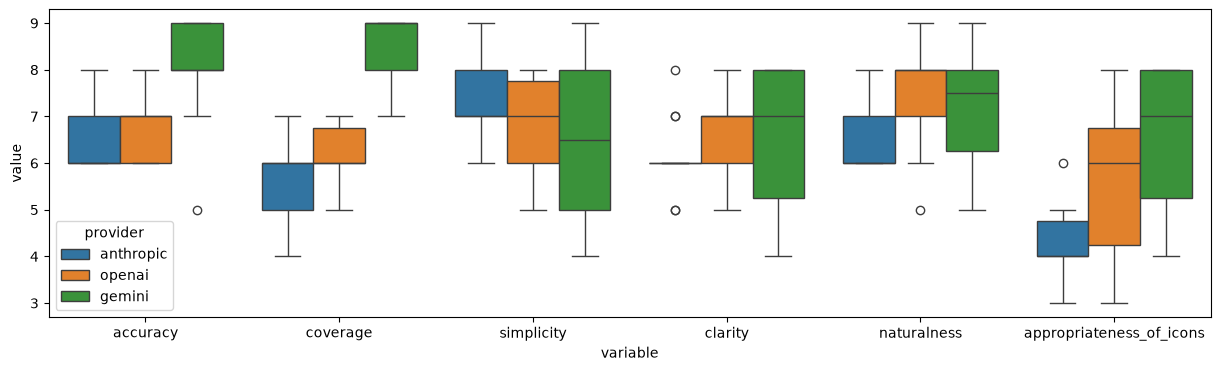

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
metrics_only = df.drop(["file", "iteration"], axis=1)
data = metrics_only.melt(id_vars="provider")
sns.boxplot(data, hue="provider", x="variable", y="value")

<Axes: xlabel='variable', ylabel='value'>

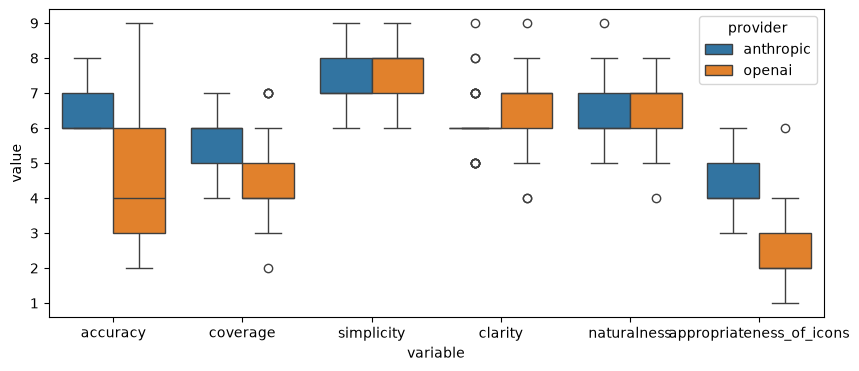

In [63]:
import seaborn as sns

plt.figure(figsize=(10, 4))
metrics_only = df.drop(["file", "iteration"], axis=1)
data = metrics_only.melt(id_vars="provider")
sns.boxplot(data, hue="provider", x="variable", y="value")

<Axes: xlabel='variable', ylabel='value'>

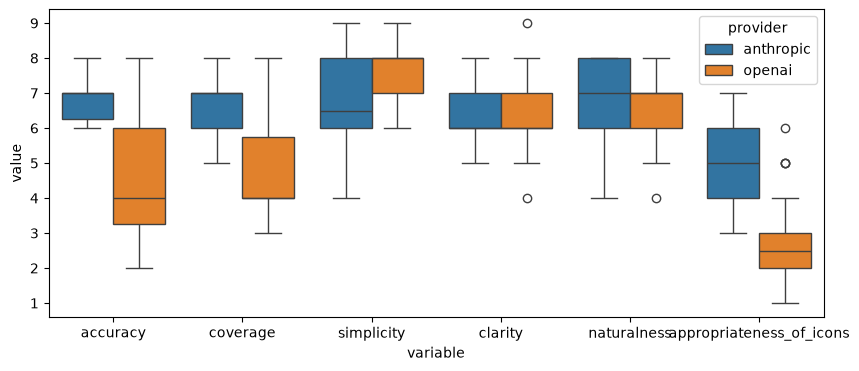

In [60]:
import seaborn as sns

plt.figure(figsize=(10, 4))
metrics_only = df.drop(["file", "iteration"], axis=1)
data = metrics_only.melt(id_vars="provider")
sns.boxplot(data, hue="provider", x="variable", y="value")

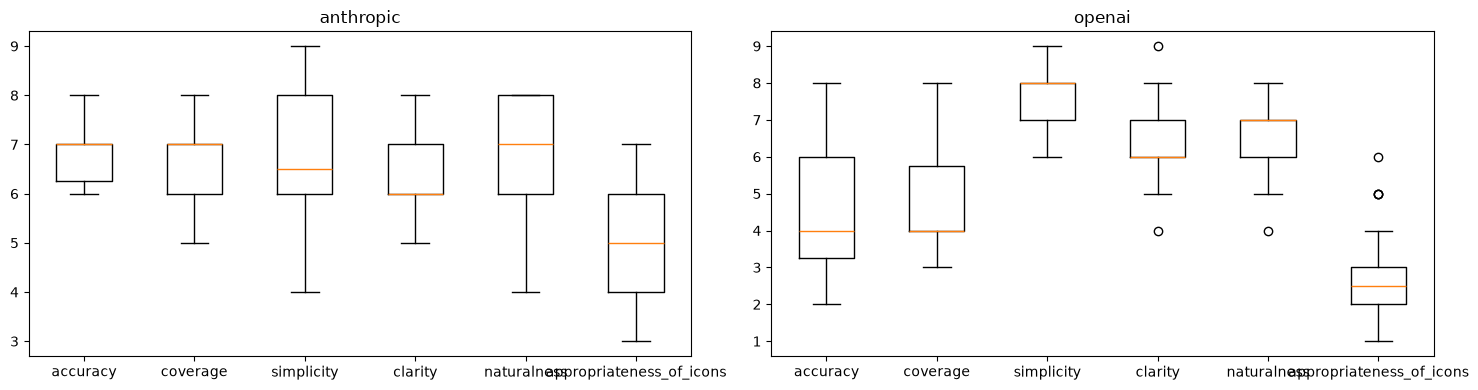

In [51]:
import seaborn as sns

METRICS = ("accuracy", "coverage", "simplicity", "clarity", "naturalness", "appropriateness_of_icons")

fig, axs = plt.subplots(1, 2, figsize=(15,4))
for ax, (rater, rater_df) in zip(axs, df.groupby("provider")):
    plt.sca(ax)
    plt.boxplot(metrics_only, showfliers=True)
    plt.gca().set_xticklabels(metrics_only.columns)
    plt.title(rater)

plt.tight_layout()

In [46]:
metrics_only


,accuracy,coverage,simplicity,clarity,naturalness,appropriateness_of_icons
3,3,4,8,6,7,3
4,3,5,8,7,6,1
5,3,4,8,6,6,2
9,6,6,8,6,7,2
10,7,6,8,7,6,2
11,6,6,9,7,8,3
15,8,8,6,7,6,4
16,8,7,8,9,8,4
17,8,7,8,8,8,5
21,6,5,9,6,8,2
